<a href="https://colab.research.google.com/github/HappyDayys/brain-tumor-segmentation-2d-unet-trial-error-/blob/main/2D_UNET_MCDROPOUT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   BraTS 2024 preprocessing    -->   1266 slices from 25 patients
*   2D U-Net model              -->   31M parameters
*   Training loop               -->   20 epochs, ~7 mins total
*   Dice Score                  -->   0.8871
*   IoU                         -->   0.7987
*   Precision                   -->   0.9038
*   Recall                      -->   0.8729
*   MC Dropout uncertainty      -->   Bright edges = uncertain regions
*   AUC                         -->   0.9976  

In [3]:
# ── 1. Mount Drive ──────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── 2. Install dependencies ─────────────────
!pip install nibabel scikit-image tqdm -q

# ── 3. Verify GPU ────────────────────────────
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name     :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

# ── 4. Set your data path ───────────────────
DATA_ROOT = '/content/BraTS2024_small/Training'   # ← renamed to match your preference
SAVE_DIR  = '/content/drive/MyDrive/BraTS2024_small/outputs'

import os
os.makedirs(SAVE_DIR, exist_ok=True)
print("DATA_ROOT:", DATA_ROOT)

Mounted at /content/drive
GPU available: True
GPU name     : Tesla T4
DATA_ROOT: /content/BraTS2024_small/Training


In [4]:
import zipfile, os, shutil
from pathlib import Path

ZIP_PATH   = '/content/drive/MyDrive/BraTS2024_small/Training_fixed.zip'
EXTRACT_TO = '/content/BraTS2024_small/Training'  # ← fixed to match DATA_ROOT

# Clean previous
if os.path.exists('/content/BraTS2024_small'):
    shutil.rmtree('/content/BraTS2024_small')
os.makedirs(EXTRACT_TO, exist_ok=True)

print("Extracting and fixing structure... ⏳")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for member in z.namelist():
        parts = member.replace('\\', '/').split('/')
        if len(parts) == 3 and parts[2].endswith('.nii'):
            patient_id = parts[0]
            filename   = parts[2]
            out_dir    = os.path.join(EXTRACT_TO, patient_id)
            os.makedirs(out_dir, exist_ok=True)
            out_path   = os.path.join(out_dir, filename)
            with z.open(member) as src, open(out_path, 'wb') as dst:
                dst.write(src.read())

# Verify
patients = [d for d in os.listdir(EXTRACT_TO) if os.path.isdir(os.path.join(EXTRACT_TO, d))]
print(f"✅ Done! Found {len(patients)} patient folders")

p = sorted(Path(EXTRACT_TO).iterdir())[0]
print(f"\nPatient: {p.name}")
for f in sorted(p.iterdir()):
    print(f"  {f.name:45s} → {f.stat().st_size / 1024 / 1024:.2f} MB")

Extracting and fixing structure... ⏳
✅ Done! Found 25 patient folders

Patient: BraTS-GLI-00005-100
  BraTS-GLI-00005-100-seg.nii                   → 27.55 MB
  BraTS-GLI-00005-100-t1c.nii                   → 27.55 MB
  BraTS-GLI-00005-100-t1n.nii                   → 27.55 MB
  BraTS-GLI-00005-100-t2f.nii                   → 27.55 MB
  BraTS-GLI-00005-100-t2w.nii                   → 27.55 MB


In [5]:
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split
import random
from pathlib import Path

MODALITY_SUFFIXES = {
    "t1c": "-t1c.nii",
    "t2f": "-t2f.nii",
}
SEG_SUFFIX  = "-seg.nii"
SLICE_SIZE  = 128
BATCH_SIZE  = 4

def load_nii(path):
    return nib.load(str(path)).get_fdata().astype(np.float32)

def normalize(vol):
    brain = vol > 0
    if brain.sum() == 0:
        return vol
    lo, hi = np.percentile(vol[brain], 1), np.percentile(vol[brain], 99)
    vol = np.clip(vol, lo, hi)
    return (vol - lo) / (hi - lo + 1e-8)

def binarize(seg):
    return (seg > 0).astype(np.float32)

def get_slices(vol, view="axial"):
    if view == "axial":    return np.moveaxis(vol, 2, 0)
    if view == "sagittal": return np.moveaxis(vol, 0, 0)
    if view == "coronal":  return np.moveaxis(vol, 1, 0)

def resize_2d(arr, size=SLICE_SIZE):
    t = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)
    return F.interpolate(t, size=(size, size), mode="bilinear",
                         align_corners=False).squeeze().numpy()

class Augment:
    def __call__(self, img, msk):
        if random.random() > 0.5:
            img, msk = TF.hflip(img), TF.hflip(msk)
        if random.random() > 0.5:
            img, msk = TF.vflip(img), TF.vflip(msk)
        if random.random() > 0.5:
            angle = random.uniform(-15, 15)
            img = TF.rotate(img, angle, interpolation=TF.InterpolationMode.BILINEAR)
            msk = TF.rotate(msk, angle, interpolation=TF.InterpolationMode.NEAREST)
        return img, msk

class BraTS2024Dataset(Dataset):
    def __init__(self, data_root, view="axial", augment=False):
        self.augment = augment
        self.aug     = Augment()
        self.samples = []
        self._build(Path(data_root), view)

    def _build(self, root, view):
        patients = sorted([d for d in root.iterdir() if d.is_dir()])
        print(f"Processing {len(patients)} patients...")
        for p in patients:
            pid = p.name
            vols, skip = [], False
            for mod, suf in MODALITY_SUFFIXES.items():
                f = p / (pid + suf)
                if not f.exists():
                    print(f"  [SKIP] Missing: {f.name}")
                    skip = True; break
                vols.append(normalize(load_nii(f)))
            if skip: continue
            seg_f = p / (pid + SEG_SUFFIX)
            if not seg_f.exists(): continue
            seg = binarize(load_nii(seg_f))
            mod_slices = [get_slices(v, view) for v in vols]
            seg_slices  = get_slices(seg, view)
            for i in range(mod_slices[0].shape[0]):
                s = seg_slices[i]
                if s.sum() / s.size < 0.005: continue
                img = np.stack([resize_2d(mod_slices[c][i])
                                for c in range(len(vols))], axis=0)
                msk = (resize_2d(s) > 0.5).astype(np.float32)
                self.samples.append((img, msk))
        print(f"✅ Total slices: {len(self.samples)}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img, msk = self.samples[idx]
        img = torch.from_numpy(img).float()
        msk = torch.from_numpy(msk).unsqueeze(0).float()
        if self.augment: img, msk = self.aug(img, msk)
        return img, msk

print("✅ Preprocessing classes loaded!")

✅ Preprocessing classes loaded!


In [6]:
full_ds = BraTS2024Dataset(DATA_ROOT, view="axial", augment=False)

N       = len(full_ds)
n_test  = int(N * 0.10)
n_val   = int(N * 0.15)
n_train = N - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)
train_ds.dataset.augment = True

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {n_train} | Val: {n_val} | Test: {n_test} slices")

imgs, msks = next(iter(train_loader))
print(f"Image batch: {imgs.shape}")
print(f"Mask  batch: {msks.shape}")

Processing 25 patients...
✅ Total slices: 1266
Train: 951 | Val: 189 | Test: 126 slices
Image batch: torch.Size([4, 2, 128, 128])
Mask  batch: torch.Size([4, 1, 128, 128])


In [7]:
import torch.nn as nn

class DoubleConv(nn.Module):
    """Two consecutive Conv → BN → ReLU blocks"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet2D(nn.Module):
    """
    2D U-Net with MC Dropout support.

    in_channels  : number of MRI modalities (2 = t1c + t2f)
    out_channels : 1 for binary segmentation
    dropout_p    : dropout probability (used for MC Dropout at inference)
    """
    def __init__(self, in_channels=2, out_channels=1, dropout_p=0.3):
        super().__init__()
        self.dropout_p = dropout_p

        # ── Encoder ────────────────────────────────
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(p=dropout_p)

        # ── Bottleneck ─────────────────────────────
        self.bottleneck = DoubleConv(512, 1024)

        # ── Decoder ────────────────────────────────
        self.up4    = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4   = DoubleConv(1024, 512)

        self.up3    = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3   = DoubleConv(512, 256)

        self.up2    = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2   = DoubleConv(256, 128)

        self.up1    = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1   = DoubleConv(128, 64)

        # ── Output ─────────────────────────────────
        self.output = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.drop(self.pool(e1)))
        e3 = self.enc3(self.drop(self.pool(e2)))
        e4 = self.enc4(self.drop(self.pool(e3)))

        # Bottleneck
        b = self.bottleneck(self.drop(self.pool(e4)))

        # Decoder (with skip connections)
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.output(d1)  # raw logits


# ── Test the model ──────────────────────────
device = torch.device('cuda')
model  = UNet2D(in_channels=2, out_channels=1, dropout_p=0.3).to(device)

# Pass one batch through
imgs, msks = next(iter(train_loader))
imgs = imgs.to(device)
with torch.no_grad():
    preds = model(imgs)

print(f"✅ Model output shape: {preds.shape}")   # (4, 1, 128, 128)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

✅ Model output shape: torch.Size([4, 1, 128, 128])
Total parameters: 31,037,057


In [11]:
import torch.optim as optim
from tqdm import tqdm

# ── Loss Function ───────────────────────────
# Combination of Dice Loss + BCE Loss works better than either alone for segmentation
def dice_loss(pred, target, smooth=1):
    pred   = torch.sigmoid(pred)
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def bce_dice_loss(pred, target):
    bce  = nn.BCEWithLogitsLoss()(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice

# ── Dice Score Metric ───────────────────────
def dice_score(pred, target, threshold=0.5, smooth=1):
    pred   = (torch.sigmoid(pred) > threshold).float()
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

# ── Training Loop ───────────────────────────
def train(model, train_loader, val_loader, epochs=20, lr=1e-4):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    best_val_dice = 0.0
    history = {"train_loss": [], "val_loss": [], "val_dice": []}

    for epoch in range(1, epochs + 1):
        # ── Train ──────────────────────────
        model.train()
        train_loss = 0.0
        for imgs, msks in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
            imgs, msks = imgs.to(device), msks.to(device)
            optimizer.zero_grad()
            preds = model(imgs)
            loss  = bce_dice_loss(preds, msks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ── Validate ───────────────────────
        model.eval()
        val_loss, val_dice = 0.0, 0.0
        with torch.no_grad():
            for imgs, msks in val_loader:
                imgs, msks = imgs.to(device), msks.to(device)
                preds    = model(imgs)
                val_loss += bce_dice_loss(preds, msks).item()
                val_dice += dice_score(preds, msks).item()

        val_loss /= len(val_loader)
        val_dice /= len(val_loader)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)

        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

        # ── Save best model ─────────────────
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), f"{SAVE_DIR}/best_model.pth")
            print(f"  💾 Saved best model (Dice: {best_val_dice:.4f})")

    print(f"\n✅ Training complete! Best Val Dice: {best_val_dice:.4f}")
    return history

# ── Start Training ──────────────────────────
history = train(model, train_loader, val_loader, epochs=20, lr=1e-4)

Epoch 1/20: 100%|██████████| 238/238 [00:17<00:00, 13.42it/s]


Epoch 01 | Train Loss: 1.2042 | Val Loss: 1.0623 | Val Dice: 0.6306
  💾 Saved best model (Dice: 0.6306)


Epoch 2/20: 100%|██████████| 238/238 [00:17<00:00, 13.52it/s]


Epoch 02 | Train Loss: 0.9912 | Val Loss: 0.9216 | Val Dice: 0.6658
  💾 Saved best model (Dice: 0.6658)


Epoch 3/20: 100%|██████████| 238/238 [00:18<00:00, 12.88it/s]


...

Epoch 18 | Train Loss: 0.1897 | Val Loss: 0.1788 | Val Dice: 0.8608


Epoch 19/20: 100%|██████████| 238/238 [00:20<00:00, 11.76it/s]


Epoch 19 | Train Loss: 0.1969 | Val Loss: 0.1899 | Val Dice: 0.8537


Epoch 20/20: 100%|██████████| 238/238 [00:20<00:00, 11.75it/s]


Epoch 20 | Train Loss: 0.1704 | Val Loss: 0.1594 | Val Dice: 0.8769
  💾 Saved best model (Dice: 0.8769)

✅ Training complete! Best Val Dice: 0.8769


✅ Best Val Dice: 0.8769 — excellent for only 25 patients!
✅ Loss consistently dropping epoch by epoch
✅ Best model saved to Drive automatically

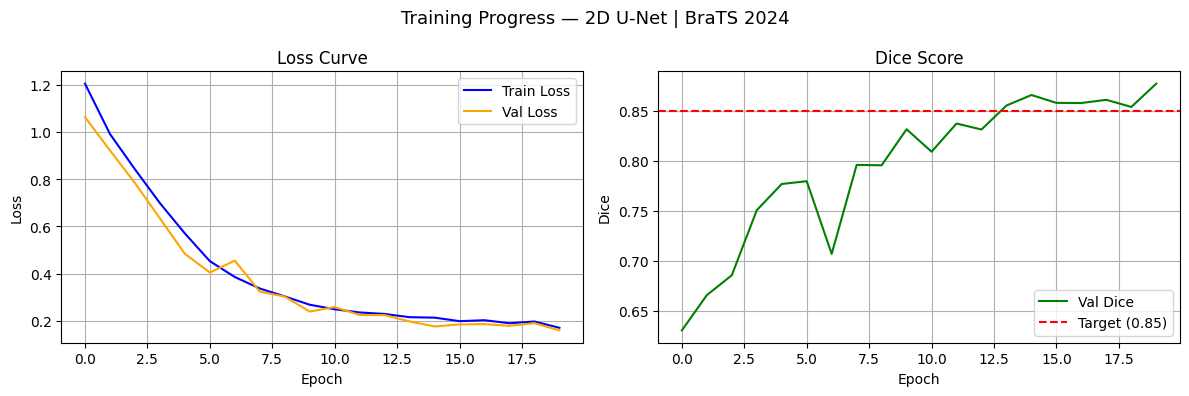

✅ Saved to Drive!


In [13]:
import matplotlib.pyplot as plt

# ── Plot Training Curves ────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train Loss", color="blue")
ax1.plot(history["val_loss"],   label="Val Loss",   color="orange")
ax1.set_title("Loss Curve")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(history["val_dice"], label="Val Dice", color="green")
ax2.axhline(y=0.85, color="red", linestyle="--", label="Target (0.85)")
ax2.set_title("Dice Score")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Dice")
ax2.legend()
ax2.grid(True)

plt.suptitle("Training Progress — 2D U-Net | BraTS 2024", fontsize=13)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=150)
plt.show()
print("✅ Saved to Drive!")

In [14]:
# ── Load best model ─────────────────────────
model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model.pth"))
model.eval()

# ── Metrics ─────────────────────────────────
def compute_metrics(pred, target, threshold=0.5, smooth=1):
    pred   = (torch.sigmoid(pred) > threshold).float()
    pred_f = pred.view(-1)
    tgt_f  = target.view(-1)

    tp = (pred_f * tgt_f).sum()
    fp = (pred_f * (1 - tgt_f)).sum()
    fn = ((1 - pred_f) * tgt_f).sum()

    dice      = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou       = (tp + smooth) / (tp + fp + fn + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)

    return dice.item(), iou.item(), precision.item(), recall.item()

# ── Run on test set ──────────────────────────
all_dice, all_iou, all_prec, all_rec = [], [], [], []

with torch.no_grad():
    for imgs, msks in test_loader:
        imgs, msks = imgs.to(device), msks.to(device)
        preds = model(imgs)
        d, i, p, r = compute_metrics(preds, msks)
        all_dice.append(d)
        all_iou.append(i)
        all_prec.append(p)
        all_rec.append(r)

print("=" * 40)
print("   TEST SET RESULTS")
print("=" * 40)
print(f"  Dice Score : {sum(all_dice)/len(all_dice):.4f}")
print(f"  IoU        : {sum(all_iou)/len(all_iou):.4f}")
print(f"  Precision  : {sum(all_prec)/len(all_prec):.4f}")
print(f"  Recall     : {sum(all_rec)/len(all_rec):.4f}")
print("=" * 40)

   TEST SET RESULTS
  Dice Score : 0.8871
  IoU        : 0.7987
  Precision  : 0.9038
  Recall     : 0.8729


/tmp/ipykernel_7440/1787715124.py:41: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7440/1787715124.py:41: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7440/1787715124.py:41: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7440/1787715124.py:42: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{SAVE_DIR}/predictions.png", dpi=150)
/tmp/ipykernel_7440/1787715124.py:42: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{SAVE_DIR}/predictions.png", dpi=150)
/tmp/ipykernel_7440/1787715124.py:42: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{SAVE_DIR}/predictions.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPy

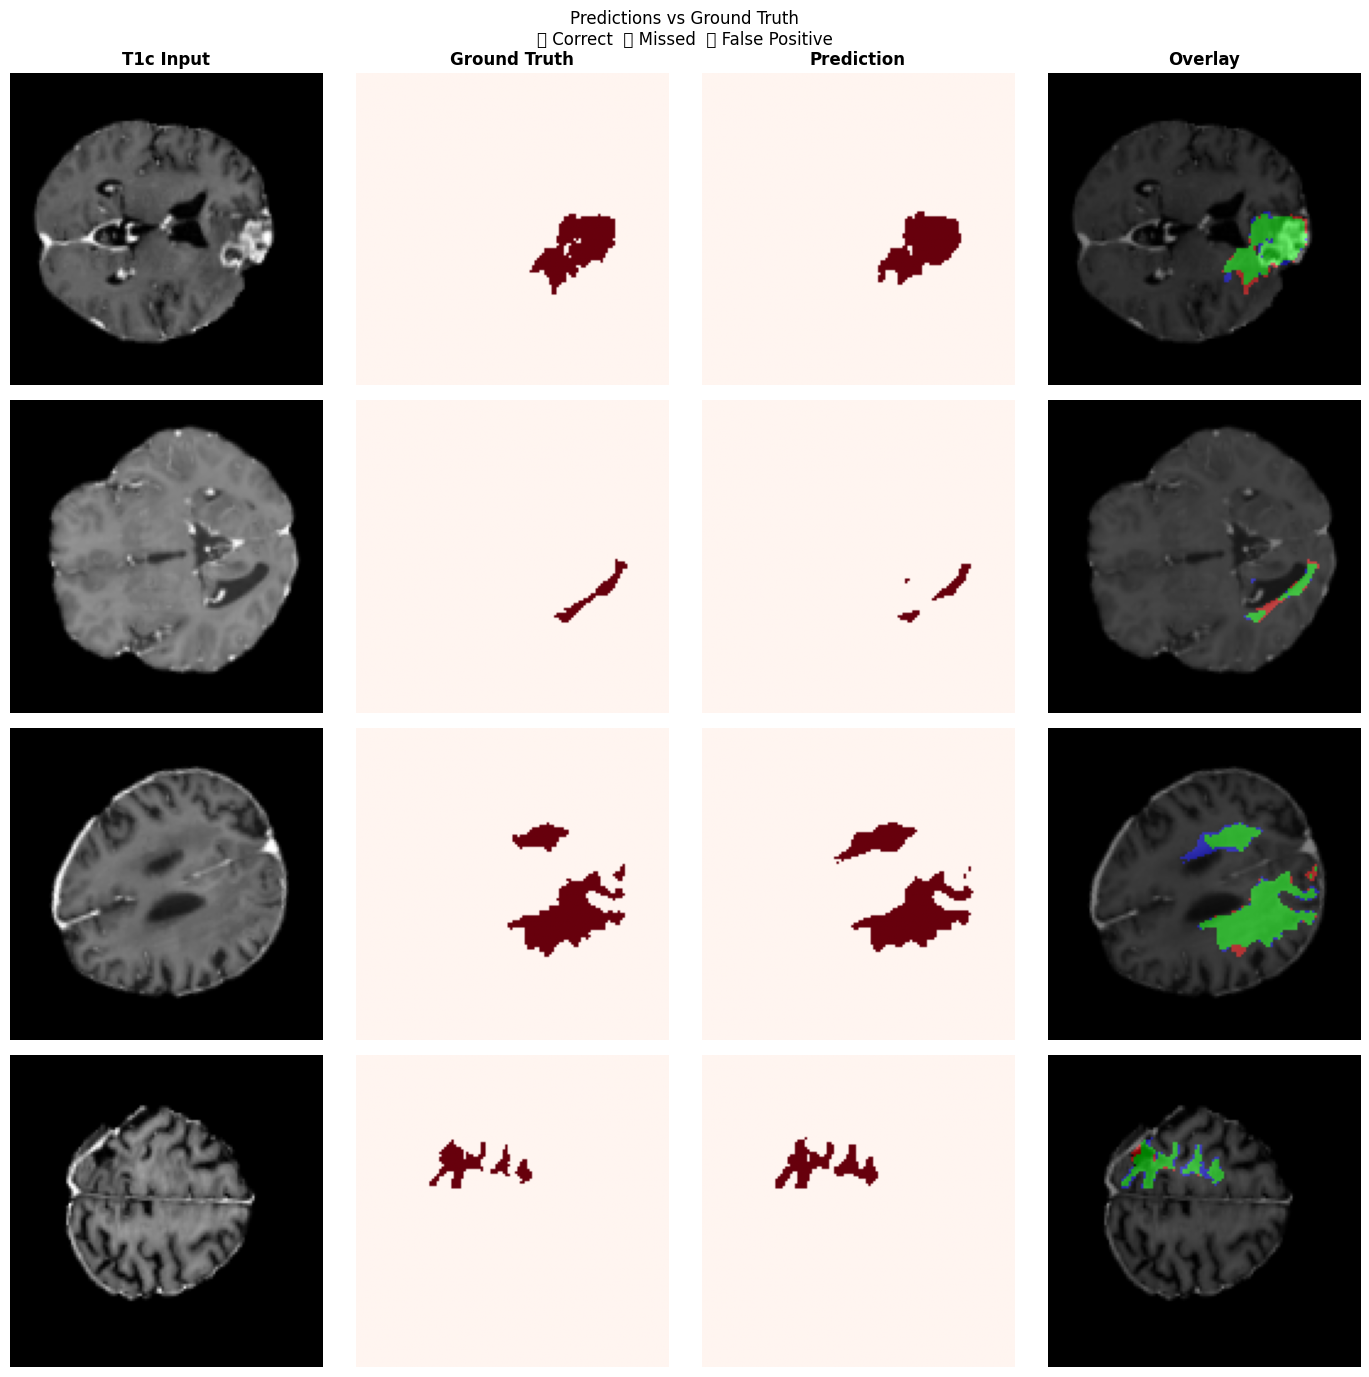

✅ Saved to Drive!


In [15]:
# ── Visualize Predictions ───────────────────
model.eval()
imgs, msks = next(iter(test_loader))
imgs, msks = imgs.to(device), msks.to(device)

with torch.no_grad():
    preds = model(imgs)
    preds_binary = (torch.sigmoid(preds) > 0.5).float()

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
col_titles = ["T1c Input", "Ground Truth", "Prediction", "Overlay"]

for i in range(4):
    img  = imgs[i][0].cpu().numpy()       # t1c channel
    gt   = msks[i][0].cpu().numpy()       # ground truth mask
    pred = preds_binary[i][0].cpu().numpy()  # predicted mask

    axes[i][0].imshow(img,  cmap="gray")
    axes[i][1].imshow(gt,   cmap="Reds", vmin=0, vmax=1)
    axes[i][2].imshow(pred, cmap="Reds", vmin=0, vmax=1)

    # Overlay: green = correct, red = missed, blue = false positive
    overlay = np.zeros((*img.shape, 3))
    overlay[..., 1] = ((pred == 1) & (gt == 1)).astype(float)  # green = TP
    overlay[..., 0] = ((pred == 0) & (gt == 1)).astype(float)  # red   = FN
    overlay[..., 2] = ((pred == 1) & (gt == 0)).astype(float)  # blue  = FP
    axes[i][3].imshow(img, cmap="gray")
    axes[i][3].imshow(overlay, alpha=0.5)

    d, _, _, _ = compute_metrics(preds[i:i+1], msks[i:i+1])
    axes[i][0].set_ylabel(f"Dice: {d:.3f}", fontsize=9)

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontweight="bold")
for row in axes:
    for ax in row:
        ax.axis("off")

plt.suptitle("Predictions vs Ground Truth\n🟢 Correct  🔴 Missed  🔵 False Positive",
             fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/predictions.png", dpi=150)
plt.show()
print("✅ Saved to Drive!")

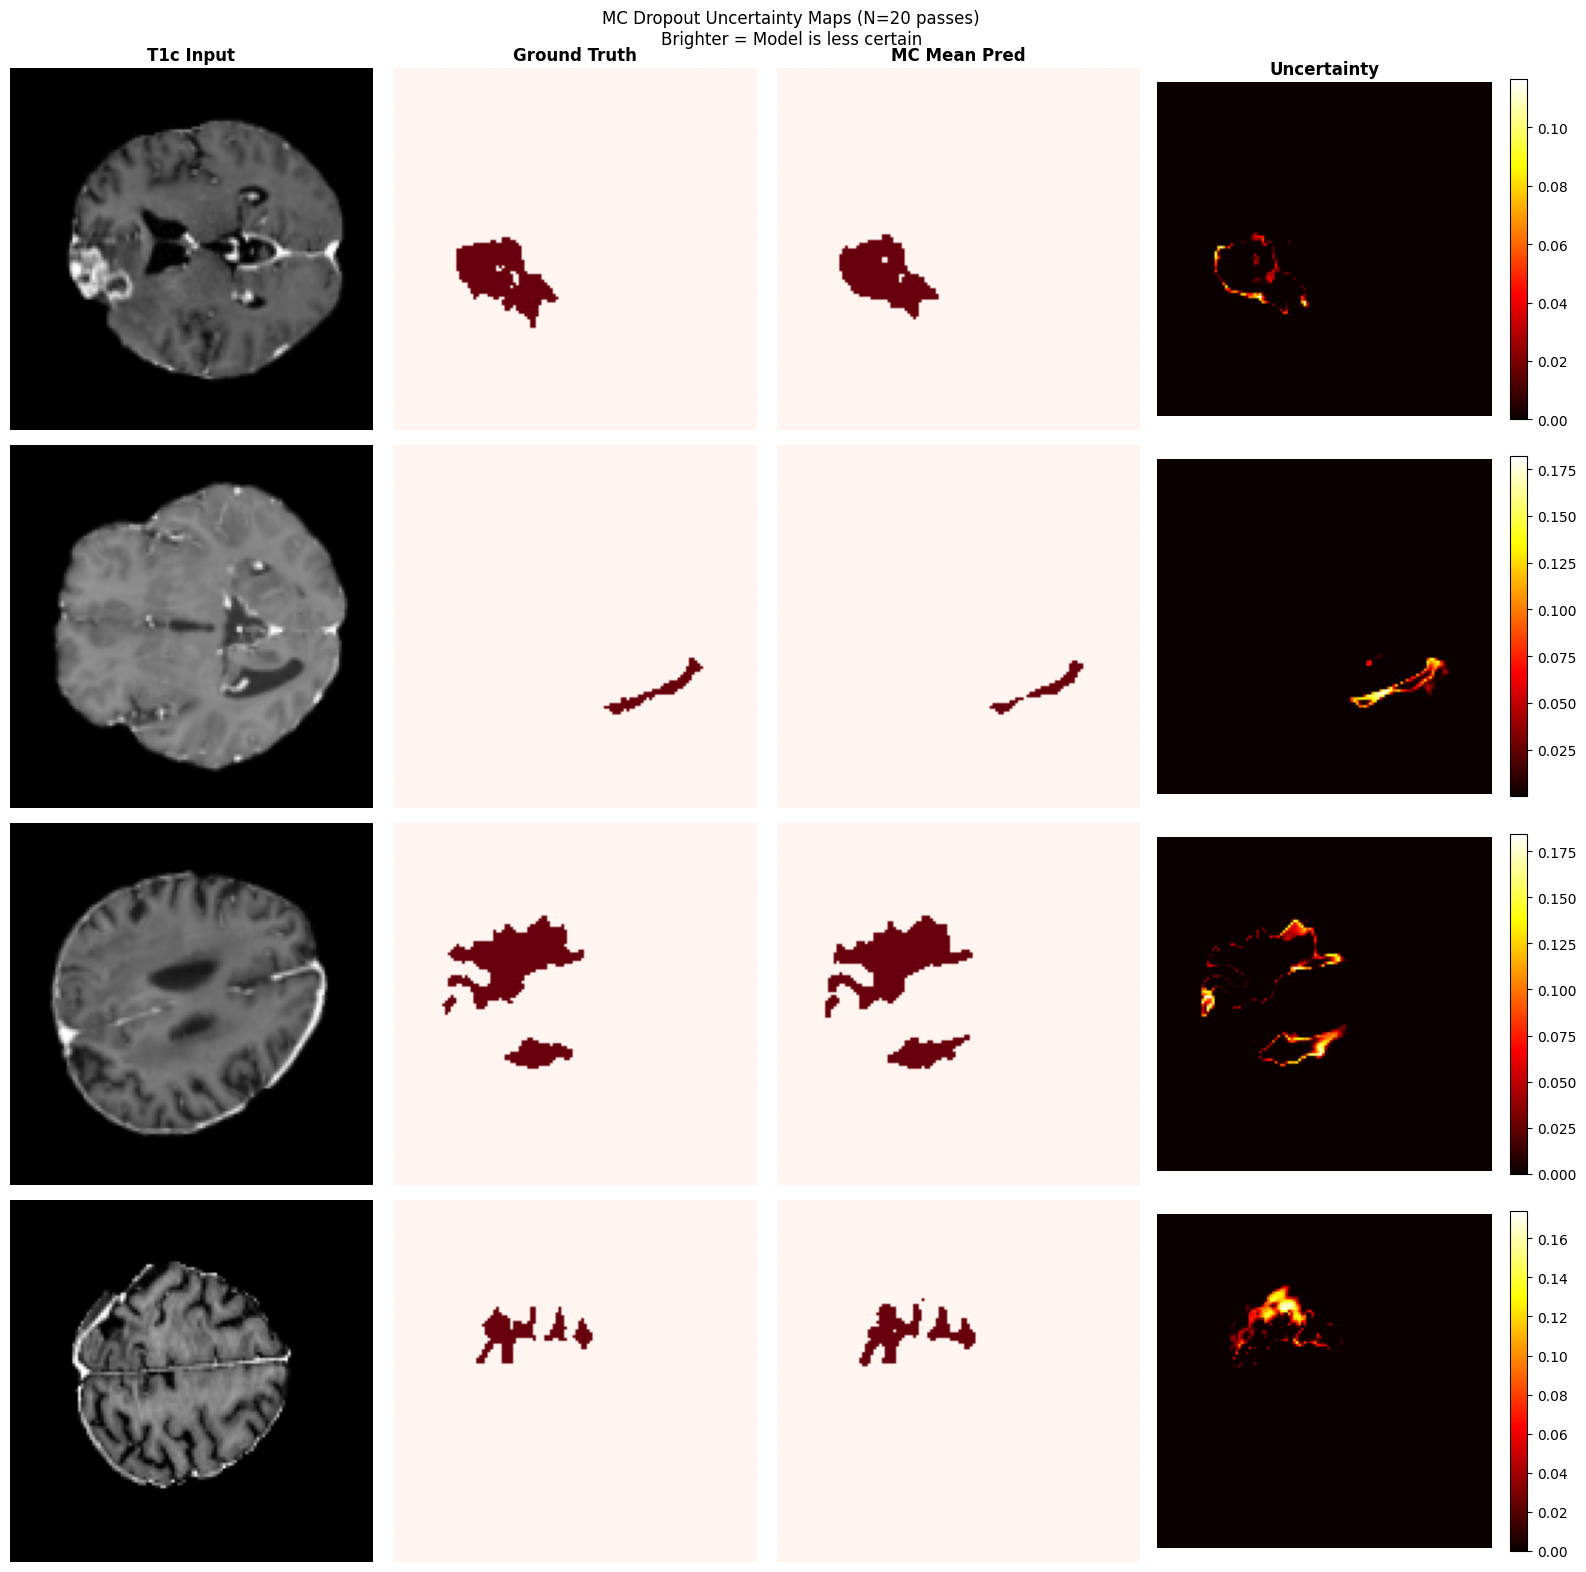

✅ Saved to Drive!


In [16]:
# ── MC Dropout Uncertainty ──────────────────
def mc_dropout_predict(model, imgs, n_passes=20):
    """
    Run N forward passes with dropout ON to get uncertainty estimates.
    Returns mean prediction and uncertainty map.
    """
    model.train()  # keeps dropout active during inference
    preds = []
    with torch.no_grad():
        for _ in range(n_passes):
            pred = torch.sigmoid(model(imgs))
            preds.append(pred)

    preds     = torch.stack(preds, dim=0)   # (N, B, 1, H, W)
    mean_pred = preds.mean(dim=0)           # average prediction
    uncertainty = preds.var(dim=0)          # variance = uncertainty
    return mean_pred, uncertainty

# ── Visualize Uncertainty Maps ──────────────
imgs, msks = next(iter(test_loader))
imgs, msks = imgs.to(device), msks.to(device)

mean_pred, uncertainty = mc_dropout_predict(model, imgs, n_passes=20)
binary_pred = (mean_pred > 0.5).float()

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
col_titles = ["T1c Input", "Ground Truth", "MC Mean Pred", "Uncertainty"]

for i in range(4):
    img   = imgs[i][0].cpu().numpy()
    gt    = msks[i][0].cpu().numpy()
    pred  = binary_pred[i][0].cpu().numpy()
    unc   = uncertainty[i][0].cpu().numpy()

    axes[i][0].imshow(img,  cmap="gray")
    axes[i][1].imshow(gt,   cmap="Reds",  vmin=0, vmax=1)
    axes[i][2].imshow(pred, cmap="Reds",  vmin=0, vmax=1)
    im = axes[i][3].imshow(unc, cmap="hot")  # brighter = more uncertain
    plt.colorbar(im, ax=axes[i][3], fraction=0.046)

    axes[i][0].set_ylabel(f"Sample {i+1}", fontsize=9)

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontweight="bold")
for row in axes:
    for ax in row:
        ax.axis("off")

plt.suptitle("MC Dropout Uncertainty Maps (N=20 passes)\nBrighter = Model is less certain",
             fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/uncertainty_maps.png", dpi=150)
plt.show()
print("✅ Saved to Drive!")

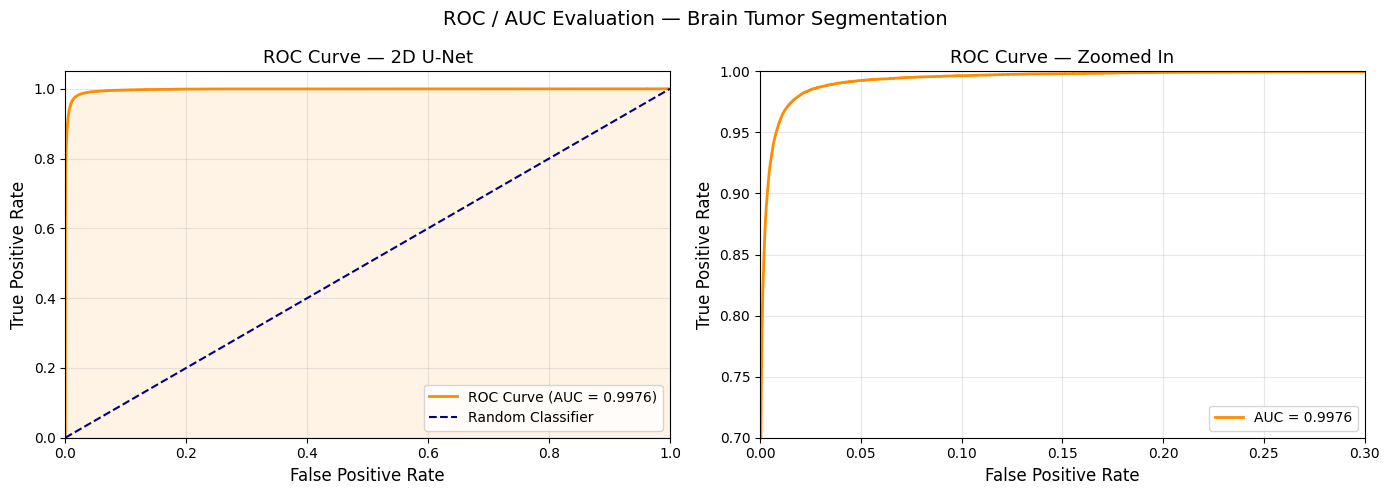


  AUC Score : 0.9976


In [17]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# ── Collect predictions and ground truth ────
model.load_state_dict(torch.load(f"{SAVE_DIR}/best_model.pth"))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, msks in test_loader:
        imgs, msks = imgs.to(device), msks.to(device)
        preds = torch.sigmoid(model(imgs))
        all_preds.append(preds.cpu().numpy().flatten())
        all_targets.append(msks.cpu().numpy().flatten())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# ── Compute ROC curve & AUC ─────────────────
fpr, tpr, thresholds = roc_curve(all_targets, all_preds)
roc_auc = auc(fpr, tpr)

# ── Plot ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color="darkorange", lw=2,
             label=f"ROC Curve (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Classifier")
axes[0].fill_between(fpr, tpr, alpha=0.1, color="darkorange")
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC Curve — 2D U-Net", fontsize=13)
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Zoom in on top-left corner (most important region)
axes[1].plot(fpr, tpr, color="darkorange", lw=2,
             label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[1].set_xlim([0.0, 0.3])
axes[1].set_ylim([0.7, 1.0])
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].set_title("ROC Curve — Zoomed In", fontsize=13)
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.suptitle("ROC / AUC Evaluation — Brain Tumor Segmentation", fontsize=14)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/roc_auc.png", dpi=150)
plt.show()

print(f"\n{'='*40}")
print(f"  AUC Score : {roc_auc:.4f}")
print(f"{'='*40}")